# 🪙 German Credit: 기본 임계값 vs. 비용 고려 임계값 (Default Threshold vs. Cost-Aware Threshold)

### 📚 **데이터셋: South German Credit**

이번 실험에서는 UCI의 **South German Credit** 데이터셋을 사용합니다.

South German Credit은 기존의 **Statlog German Credit** 데이터를 기반으로 한 보정 버전입니다.
UCI 설명에 따르면 기존 Statlog German Credit의 코딩 정보 오류와 부족한 배경 설명을 보완하기 위해 제공된 데이터셋입니다.

- **Statlog German Credit** → 기존에 널리 사용된 원본 계열 데이터셋
- **South German Credit** → 동일한 데이터를 기반으로 코딩 정보와 변수 설명을 보완한 버전

이번 프로젝트에서는 변수 정의와 코드 해석이 더 명확한 **South German Credit**을 분석 데이터로 사용합니다.

🔗 [UCI - South German Credit](https://archive.ics.uci.edu/dataset/522/south+german+credit)  
🔗 [UCI - Statlog German Credit](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data)

---

### 📚 **Dataset: South German Credit**

This experiment uses the **South German Credit** dataset from the UCI Machine Learning Repository.

South German Credit is a corrected version based on the original **Statlog German Credit** dataset.  
According to UCI, it was provided to address coding-information errors and insufficient background documentation in the original Statlog German Credit data.

- **Statlog German Credit** → the widely used original version of the dataset
- **South German Credit** → a revised version with improved coding information and variable descriptions

This project uses **South German Credit** because its variable definitions and code interpretations are clearer.

🔗 [UCI - South German Credit](https://archive.ics.uci.edu/dataset/522/south+german+credit)  
🔗 [UCI - Statlog German Credit](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data)

UCI에서 다운로드한 폴더의 압축을 해제하는 과정에서 `codetable.txt` 파일로 인해 반복적으로 오류가 발생했습니다.

- `codetable.txt`는 데이터셋 설명 파일이므로 제외하고 데이터 파일만 사용할 수도 있지만, 이번에는 대안으로 `UCI ZIP` 방식을 사용했습니다.

**UCI ZIP이란?**

- UCI Machine Learning Repository에서 데이터 파일을 ZIP 형태로 직접 다운로드하는 방식
- 압축 파일을 다운로드하고 해제한 뒤 CSV 등의 데이터 파일을 사용하는 방식

```text
UCI Repository
      ↓
ZIP 파일 다운로드
      ↓
압축 해제
      ↓
CSV 등 데이터 파일 불러오기
```

---

An error repeatedly occurred while extracting the folder downloaded from UCI because of the `codetable.txt` file.

- Since `codetable.txt` is a dataset-description file, the analysis could proceed using only the data file. In this project, however, the `UCI ZIP` approach was used as an alternative.

**What is UCI ZIP?**

- A method of downloading dataset files directly from the UCI Machine Learning Repository as a ZIP archive
- The archive is downloaded and extracted before loading the actual data file, such as a CSV or text-based dataset

```text
UCI Repository
      ↓
Download ZIP file
      ↓
Extract archive
      ↓
Load CSV or other data file
```

# 1. 데이터 불러오기 및 확인 (Load and Verify Data)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [ ]:
# UCI ZIP 바로 받기 (Download UCI ZIP)
!wget -q "https://archive.ics.uci.edu/static/public/522/south+german+credit.zip" -O south_german_credit.zip

!unzip -o south_german_credit.zip

Archive:  south_german_credit.zip
 bunzipping: codetable.txt           
 bunzipping: read_SouthGermanCredit.R  
 bunzipping: SouthGermanCredit.asc   


In [ ]:
# 다운받은 파일 확인 (Check Downloaded Files)
!ls

codetable.txt		  sample_data		 south_german_credit.zip
read_SouthGermanCredit.R  SouthGermanCredit.asc


In [ ]:
df = pd.read_csv("SouthGermanCredit.asc")

In [ ]:
df

,laufkont laufzeit moral verw hoehe sparkont beszeit rate famges buerge wohnzeit verm alter weitkred wohn bishkred beruf pers telef gastarb kredit
0,1 18 4 2 1049 1 2 4 2 1 4 2 21 3 1 1 3 2 1 2 1
1,1 9 4 0 2799 1 3 2 3 1 2 1 36 3 1 2 3 1 1 2 1
2,2 12 2 9 841 2 4 2 2 1 4 1 23 3 1 1 2 2 1 2 1
3,1 12 4 0 2122 1 3 3 3 1 2 1 39 3 1 2 2 1 1 1 1
4,1 12 4 0 2171 1 3 4 3 1 4 2 38 1 2 2 2 2 1 1 1
...,...
995,1 24 2 3 1987 1 3 2 3 1 4 1 21 3 1 1 2 1 1 2 0
996,1 24 2 0 2303 1 5 4 3 2 1 1 45 3 2 1 3 2 1 2 0
997,4 21 4 0 12680 5 5 4 3 1 4 4 30 3 3 1 4 2 2 2 0
998,2 12 2 3 6468 5 1 2 3 1 1 4 52 3 2 1 4 2 2 2 0


=> 공백을 기준으로 값이 구분된 텍스트 문서입니다.

---

=> A text file in which values are separated by whitespace.

In [ ]:
df = pd.read_csv("SouthGermanCredit.asc", sep=r"\s+")
# sep=r"\s+": 하나 이상의 공백(띄어쓰기, 탭 등)을 컬럼 구분자로 지정 (Use one or more whitespace characters as column separators)
df

,laufkont,laufzeit,moral,verw,hoehe,sparkont,beszeit,rate,famges,buerge,...,verm,alter,weitkred,wohn,bishkred,beruf,pers,telef,gastarb,kredit
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,24,2,3,1987,1,3,2,3,1,...,1,21,3,1,1,2,1,1,2,0
996,1,24,2,0,2303,1,5,4,3,2,...,1,45,3,2,1,3,2,1,2,0
997,4,21,4,0,12680,5,5,4,3,1,...,4,30,3,3,1,4,2,2,2,0
998,2,12,2,3,6468,5,1,2,3,1,...,4,52,3,2,1,4,2,2,2,0


In [ ]:
# 컬럼 이름을 독어 -> 영문으로 변환 (Rename Columns from German to English)

df = df.rename(columns={
    "laufkont": "status",
    "laufzeit": "duration",
    "moral": "credit_history",
    "verw": "purpose",
    "hoehe": "amount",
    "sparkont": "savings",
    "beszeit": "employment_duration",
    "rate": "installment_rate",
    "famges": "personal_status_sex",
    "buerge": "other_debtors",
    "wohnzeit": "present_residence",
    "verm": "property",
    "alter": "age",
    "weitkred": "other_installment_plans",
    "wohn": "housing",
    "bishkred": "number_credits",
    "beruf": "job",
    "pers": "people_liable",
    "telef": "telephone",
    "gastarb": "foreign_worker",
    "kredit": "credit_risk"
})

In [ ]:
# 컬럼명 변환 확인 (Verify Renamed Columns)
df.head()

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1


In [ ]:
df.shape

(1000, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   status                   1000 non-null   int64
 1   duration                 1000 non-null   int64
 2   credit_history           1000 non-null   int64
 3   purpose                  1000 non-null   int64
 4   amount                   1000 non-null   int64
 5   savings                  1000 non-null   int64
 6   employment_duration      1000 non-null   int64
 7   installment_rate         1000 non-null   int64
 8   personal_status_sex      1000 non-null   int64
 9   other_debtors            1000 non-null   int64
 10  present_residence        1000 non-null   int64
 11  property                 1000 non-null   int64
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   int64
 14  housing                  1000 non-null   int64
 15  numbe

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
status,1000.0,2.577,1.257638,1.0,1.0,2.0,4.00,4.0
duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
credit_history,1000.0,2.545,1.083120,0.0,2.0,2.0,4.00,4.0
purpose,1000.0,2.828,2.744439,0.0,1.0,2.0,3.00,10.0
amount,1000.0,3271.248,2822.751760,250.0,1365.5,2319.5,3972.25,18424.0
savings,1000.0,2.105,1.580023,1.0,1.0,1.0,3.00,5.0
employment_duration,1000.0,3.384,1.208306,1.0,3.0,3.0,5.00,5.0
installment_rate,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
personal_status_sex,1000.0,2.682,0.708080,1.0,2.0,3.0,3.00,4.0
other_debtors,1000.0,1.145,0.477706,1.0,1.0,1.0,1.00,3.0


### 📊 1차 데이터 확인 요약

- **데이터 크기**: 총 1,000개의 행과 21개의 열로 구성
- **결측치**: 모든 컬럼에 결측치가 없는 것으로 보이나 추가 확인 필요
- **데이터 타입**
    - 대부분의 컬럼이 범주형 데이터를 숫자로 라벨링한 형태
    - 특히 이번 데이터셋은 많은 변수가 category code로 저장되어 있어 변수 의미에 대한 확인과 적절한 처리가 필요

- **우측 치우침 컬럼**
    - status, duration, credit_history, purpose, amount, savings, employment_duration, other_debtors, property, age, number_credits, telephone

- **컬럼 분포 (`df.describe()` 기반)**
    - **status, credit_history, purpose**: 범주형이며 특정 값에 분포가 집중되어 있을 가능성이 있음
    - **duration**: 대출 기간. 평균 대비 최대값이 매우 높아 우측으로 치우친 분포이며 짧은 대출 기간이 다수
    - **amount**: 대출 금액. 표준편차가 크고 최대값이 평균보다 월등히 높아 심한 우측 치우침을 보이며 소액 대출이 주를 이룸
    - **savings, employment_duration**: 범주형 특성. 저축액이 적거나 특정 고용 기간에 집중된 양상
    - **installment_rate, personal_status_sex**: 범주형 특성
    - **other_debtors**: 대부분 '다른 채무자 없음'에 집중된 편향된 분포
    - **present_residence, property**: 범주형 특성
    - **age**: 평균 35.5세. 비교적 고른 분포지만 젊은 연령대에 약간 집중된 경향
    - **other_installment_plans**: 대부분 '다른 계획 없음'에 집중된 편향
    - **housing, number_credits, job**: 범주형 특성. `number_credits`는 1개인 경우의 비중이 큼
    - **people_liable**: 대부분 '부양 가족 있음'에 집중된 분포
    - **telephone**: 대부분 '전화 없음'에 집중된 분포
    - **foreign_worker**: 대부분 '외국인 노동자 아님'에 집중된 분포
    - **credit_risk**: 신용 위험 타겟 변수. 0(Bad)과 1(Good) 중 1의 비율이 70%로 클래스 불균형 존재

---

### 📊 Initial Data Check Summary

- **Dataset size**: 1,000 rows and 21 columns
- **Missing values**: no missing values appear to be present, but an additional check is required
- **Data types**
    - Most columns represent categorical information encoded with numeric labels
    - Many variables are stored as category codes, so their meanings and appropriate preprocessing methods need to be examined carefully

- **Right-skewed columns**
    - status, duration, credit_history, purpose, amount, savings, employment_duration, other_debtors, property, age, number_credits, telephone

- **Column distributions based on `df.describe()`**
    - **status, credit_history, purpose**: categorical variables that may be concentrated in particular categories
    - **duration**: loan duration. The maximum is much larger than the mean, indicating a right-skewed distribution with many shorter-duration loans
    - **amount**: loan amount. The large standard deviation and maximum relative to the mean indicate a strongly right-skewed distribution dominated by smaller loans
    - **savings, employment_duration**: categorical features with observations concentrated in lower savings levels or particular employment-duration groups
    - **installment_rate, personal_status_sex**: categorical features
    - **other_debtors**: distribution is heavily concentrated in the 'no other debtors' category
    - **present_residence, property**: categorical features
    - **age**: mean age is 35.5 years. The distribution is relatively broad but somewhat concentrated among younger customers
    - **other_installment_plans**: heavily concentrated in the 'no other plans' category
    - **housing, number_credits, job**: categorical features. `number_credits` is heavily concentrated at one credit
    - **people_liable**: concentrated in the category indicating dependents
    - **telephone**: concentrated in the 'no telephone' category
    - **foreign_worker**: concentrated in the 'not a foreign worker' category
    - **credit_risk**: target variable for credit risk. Class 1 (Good) represents 70% of the observations, indicating class imbalance

# 2. 추가 데이터 확인 및 데이터 전처리 (Additional Data Verification and Preprocessing)

In [ ]:
# 종속변수 라벨별 개수 확인 (Check Target Class Counts)
df["credit_risk"].value_counts()

,count
credit_risk,
1,700
0,300


### 타겟 변수 재정의

- 기존: `1 = Good`, `0 = Bad`
- 변경: `0 = Good`, `1 = Bad`

즉, 실제로 예측하고 이후 성능을 중점적으로 확인할 **Bad Credit**을 타겟 클래스 `1`로 지정합니다.

---

### Redefining the Target Variable

- Original: `1 = Good`, `0 = Bad`
- Revised: `0 = Good`, `1 = Bad`

In other words, **Bad Credit**, which is the class of primary interest in this experiment, is reassigned as the positive target class `1`.

In [ ]:
df["credit_risk"] = df["credit_risk"].map({
    1: 0,
    0: 1
})

In [ ]:
df["credit_risk"].value_counts()

,count
credit_risk,
0,700
1,300


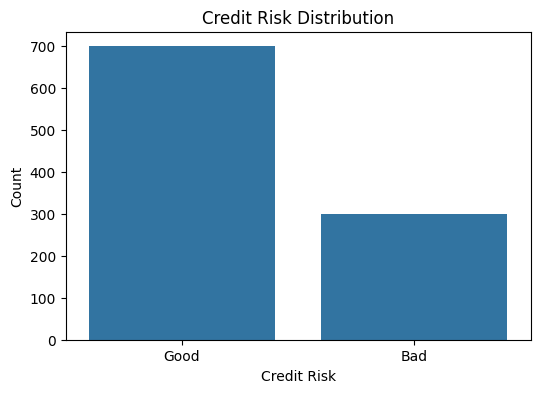

In [ ]:
# 타겟 분포 시각화 (Visualize Target Distribution)
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="credit_risk")

plt.title("Credit Risk Distribution")
plt.xlabel("Credit Risk")
plt.ylabel("Count")
plt.xticks([0, 1], ["Good", "Bad"])

plt.show()

### 결측치 / 중복 확인

---

### Check for Missing Values and Duplicates

In [ ]:
# 결측치 한 번 확인 (Check Missing Values)

df.isnull().sum()

,0
status,0
duration,0
credit_history,0
purpose,0
amount,0
savings,0
employment_duration,0
installment_rate,0
personal_status_sex,0
other_debtors,0


In [ ]:
# 중복값 확인 (Check Duplicate Rows)

df.duplicated().sum()

np.int64(0)

### 데이터 타입 정리

- 실제 데이터 타입은 `int64`로 표시되지만, 대부분은 숫자로 인코딩된 범주형 변수입니다.
- 실제 수치적 의미를 가지는 변수는 numeric feature로 유지하고, 그렇지 않은 변수는 categorical feature로 별도 관리합니다.

---

### Organizing Feature Types

- Although the raw data types are shown as `int64`, most variables are categorical features encoded with numeric values.
- Variables with genuine quantitative meaning are kept as numeric features, while the remaining variables are handled separately as categorical features.

In [ ]:
# 수치형 변수 (Numeric Features)

numeric_features = ["duration", "amount", "age"]

In [ ]:
# 범주형 변수 (Categorical Features)

categorical_features = [
    col for col in df.columns
    if col not in numeric_features + ["credit_risk"]
]

# 3. 모델링 (Modeling)

### 독립변수 / 종속변수 분리

---

### Separating Features and Target

In [ ]:
X = df.drop(columns=["credit_risk"])
y = df["credit_risk"]

In [ ]:
X.shape

(1000, 20)

In [ ]:
y.shape

(1000,)

### 학습 / 확인 / 테스트 데이터셋 분리

- 학습(Train) → 모델 학습
- 확인(Validation) → 비용 고려 임계값(Cost-Aware Threshold) 탐색
- 테스트(Test) → 기본 임계값 0.5와 비용 고려 임계값 최종 비교

---

### Train / Validation / Test Split

- **Train** → train the model
- **Validation** → identify the Cost-Aware Threshold
- **Test** → make the final comparison between the default threshold of 0.5 and the Cost-Aware Threshold

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
# 80%에서 학습과 확인 데이터셋 나누기 (Split the Remaining 80% into Train and Validation Sets)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=42
)

In [ ]:
X_train.shape

(600, 20)

In [ ]:
X_val.shape

(200, 20)

In [ ]:
X_test.shape

(200, 20)

#### 🔄 ColumnTransformer

`ColumnTransformer`는 **컬럼 그룹별로 서로 다른 전처리를 적용할 수 있게 해주는 도구**입니다.  
변수 유형에 따라 필요한 전처리를 하나의 과정으로 관리할 수 있다는 장점이 있습니다.

이번 실험에서는:

- `numeric_features` → `StandardScaler()` 적용
- `categorical_features` → `OneHotEncoder()` 적용

즉, 하나의 데이터프레임 안에서 숫자형 변수와 범주형 변수에 서로 다른 전처리를 적용한 뒤, 변환된 결과를 하나의 모델 입력 데이터로 결합합니다.

---

#### 🔄 ColumnTransformer

`ColumnTransformer` allows **different preprocessing methods to be applied to different groups of columns**.  
Its main advantage is that preprocessing for multiple feature types can be managed within a single workflow.

In this experiment:

- `numeric_features` → apply `StandardScaler()`
- `categorical_features` → apply `OneHotEncoder()`

In other words, numeric and categorical variables are transformed separately and then combined into a single input dataset for the model.

In [ ]:
# 컬럼트랜스포머 진행 (Configure ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

### 로지스틱 회귀 모델링

---

### Logistic Regression Modeling

In [ ]:
# 컬럼 트랜스포머와 로지스틱 회귀 연결 (Connect ColumnTransformer and Logistic Regression)
model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

In [ ]:
# 학습 (Train the Model)

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['duration', 'amount',
                                                   'age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['status', 'credit_history',
                                                   'purpose', 'savings',
                                                   'employment_duration',
                                                   'installment_rate',
                                                   'personal_status_sex',
                                                   'other_debtors',
                                                   'present_residence',
                                                   'property',
                                                   'other_installment_plans',
                                                   'housing', 'number_credits',
                                                   'job', 'people_liable',
                                                   'telephone',
                                                   'foreign_worker'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

# 4. 실험 시작 - 기본 임계값 0.5 (Experiment 1 - Default Threshold of 0.5)

#### 🎯 Logistic Regression의 기본 임계값

scikit-learn의 이진 분류에서 `predict()`는 클래스 라벨을 결정할 때 기본적으로 `predict_proba()`에서 계산된 확률을 기준으로 분류합니다.

별도의 임계값을 지정하지 않으면 다음과 같이 해석할 수 있습니다.

```text
Predicted Probability < 0.5  →  Class 0
Predicted Probability ≥ 0.5  →  Class 1
```

**=> 기본 임계값: 0.5**

- 관련 문서 [바로가기](https://scikit-learn.org/stable/modules/classification_threshold.html)

---

#### 🎯 Default Threshold in Logistic Regression

In scikit-learn binary classification, `predict()` assigns class labels using the model's predicted probability.

Without specifying a separate decision threshold, the classification rule can be interpreted as:

```text
Predicted Probability < 0.5  →  Class 0
Predicted Probability ≥ 0.5  →  Class 1
```

**=> Default threshold: 0.5**

- [scikit-learn documentation](https://scikit-learn.org/stable/modules/classification_threshold.html)

In [ ]:
# 결과 (Results)
y_val_pred = model.predict(X_val)

### 평가

---

### Evaluation

In [ ]:
print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall   :", recall_score(y_val, y_val_pred))
print("F1 Score :", f1_score(y_val, y_val_pred))

Accuracy : 0.755
Precision: 0.6037735849056604
Recall   : 0.5333333333333333
F1 Score : 0.5663716814159292


#### 💰 오분류 비용과 오차 행렬 (Confusion Matrix)

이번 실험의 타겟 정의:

- `0` → Good Credit
- `1` → Bad Credit

즉, **Bad Credit을 Positive Class로 설정**한 상태입니다.

이 기준에서 Confusion Matrix는 다음과 같이 해석합니다.

| 실제 / 예측 | Good (0) | Bad (1) |
|---|---:|---:|
| **Good (0)** | TN | FP |
| **Bad (1)** | FN | TP |

각 항목의 의미:

- `TN` → 실제 Good을 Good으로 예측한 경우
- `FP` → 실제 Good을 Bad로 잘못 예측한 경우
- `FN` → 실제 Bad를 Good으로 잘못 예측한 경우
- `TP` → 실제 Bad를 Bad로 예측한 경우

이번 데이터에서는 두 종류의 오분류에 동일한 비용을 적용하지 않습니다.

- **Good → Bad** → `FP` → 비용 1
- **Bad → Good** → `FN` → 비용 5

Bad 고객을 Good으로 판단하는 오류가 더 큰 손실로 이어질 수 있다는 가정에 따라 `FN`에 5배의 비용을 부여합니다.

따라서 전체 오분류 비용은 다음과 같이 계산합니다.

```math
Cost = 1 × FP + 5 × FN
```

> 💡 오분류 비용의 `1:5` 비율은 임의로 설정한 값이 아니라, 원본 **Statlog German Credit**에 제시된 Cost Matrix를 적용한 값입니다.  
> 실제 Good을 Bad로 예측한 경우 비용 `1`, 실제 Bad를 Good으로 예측한 경우 비용 `5`로 설정되어 있으며, 본 실험에서도 동일한 비용 구조를 사용합니다.  
> 🔗 [UCI - Statlog German Credit Cost Matrix](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data)

---

#### 💰 Misclassification Cost and Confusion Matrix

Target definition used in this experiment:

- `0` → Good Credit
- `1` → Bad Credit

Therefore, **Bad Credit is defined as the positive class**.

Under this definition, the Confusion Matrix is interpreted as follows:

| Actual / Predicted | Good (0) | Bad (1) |
|---|---:|---:|
| **Good (0)** | TN | FP |
| **Bad (1)** | FN | TP |

Meaning of each outcome:

- `TN` → actual Good correctly predicted as Good
- `FP` → actual Good incorrectly predicted as Bad
- `FN` → actual Bad incorrectly predicted as Good
- `TP` → actual Bad correctly predicted as Bad

The two types of misclassification are not assigned the same cost.

- **Good → Bad** → `FP` → cost 1
- **Bad → Good** → `FN` → cost 5

Because incorrectly classifying a Bad customer as Good can lead to a larger loss, a five-times-higher cost is assigned to `FN`.

The total misclassification cost is therefore calculated as:

```math
Cost = 1 × FP + 5 × FN
```

> 💡 The `1:5` cost ratio is not arbitrary. It follows the Cost Matrix provided with the original **Statlog German Credit** dataset.  
> Misclassifying an actual Good customer as Bad has a cost of `1`, while misclassifying an actual Bad customer as Good has a cost of `5`. The same cost structure is used in this experiment.  
> 🔗 [UCI - Statlog German Credit Cost Matrix](https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data)

In [ ]:
# 오분류 비용 계산 함수 (Misclassification Cost Function)
def calculate_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    # Cost = 1×FP + 5×FN
    return fp + (5 * fn)

In [ ]:
# 임계값 비용 확인 (Check Cost at the Default Threshold)
default_cost = calculate_cost(y_val, y_val_pred)

print("Default Threshold Cost:", default_cost)

Default Threshold Cost: 161


# 5. 실험 - `predict_proba()`를 이용한 임계값 탐색 (Experiment 2 - Threshold Search Using `predict_proba()`)

In [ ]:
y_val_prob = model.predict_proba(X_val)[:, 1]

In [ ]:
# 확인 (Check Results)
y_val_prob[:10]

array([0.05590972, 0.81305929, 0.21821322, 0.44769857, 0.05896119,
       0.27540784, 0.11820628, 0.10458315, 0.5567387 , 0.06052922])

In [ ]:
# 여러 임계값 지정 (Define Multiple Thresholds)

thresholds = np.arange(0.05, 0.96, 0.01)

In [ ]:
# 임계값 마다 결과 저장 (Store Results for Each Threshold)

results = []

for threshold in thresholds:

    y_pred_threshold = (
        y_val_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred_threshold,
        labels=[0, 1]
    ).ravel()

    cost = fp + (5 * fn)

    results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(
            y_val,
            y_pred_threshold
        ),
        "precision": precision_score(
            y_val,
            y_pred_threshold,
            zero_division=0
        ),
        "recall": recall_score(
            y_val,
            y_pred_threshold,
            zero_division=0
        ),
        "f1": f1_score(
            y_val,
            y_pred_threshold,
            zero_division=0
        ),
        "false_positive": fp,
        "false_negative": fn,
        "cost": cost
    })

In [ ]:
# 위의 결과 데이터 프레임으로 (Convert Results to a DataFrame)

threshold_results = pd.DataFrame(results)

threshold_results

,threshold,accuracy,precision,recall,f1,false_positive,false_negative,cost
0,0.05,0.445,0.350877,1.000000,0.519481,111,0,111
1,0.06,0.465,0.357576,0.983333,0.524444,106,1,111
2,0.07,0.490,0.367089,0.966667,0.532110,100,2,110
3,0.08,0.500,0.370130,0.950000,0.532710,97,3,112
4,0.09,0.505,0.369128,0.916667,0.526316,94,5,119
...,...,...,...,...,...,...,...,...
86,0.91,0.705,1.000000,0.016667,0.032787,0,59,295
87,0.92,0.705,1.000000,0.016667,0.032787,0,59,295
88,0.93,0.705,1.000000,0.016667,0.032787,0,59,295
89,0.94,0.705,1.000000,0.016667,0.032787,0,59,295


=> 전체적으로 임계값이 커질수록 정확도와 정밀도는 높아지는 반면, 재현율과 F1 Score는 낮아지는 경향을 보입니다.

---

=> Overall, as the decision threshold increases, accuracy and precision tend to increase, while recall and the F1 Score tend to decrease.

### 비용이 가장 낮은 임계값 찾기

---

### Finding the Threshold with the Lowest Cost

In [ ]:
best_row = threshold_results.loc[
    threshold_results["cost"].idxmin()
]

best_row

,23
threshold,0.280000
accuracy,0.700000
precision,0.500000
recall,0.816667
f1,0.620253
false_positive,49.000000
false_negative,11.000000
cost,104.000000


In [ ]:
# 베스트 임계값 따로 저장 (Save the Best Threshold)

best_threshold = best_row["threshold"]

### 임계값별 비용 그래프

---

### Misclassification Cost by Threshold

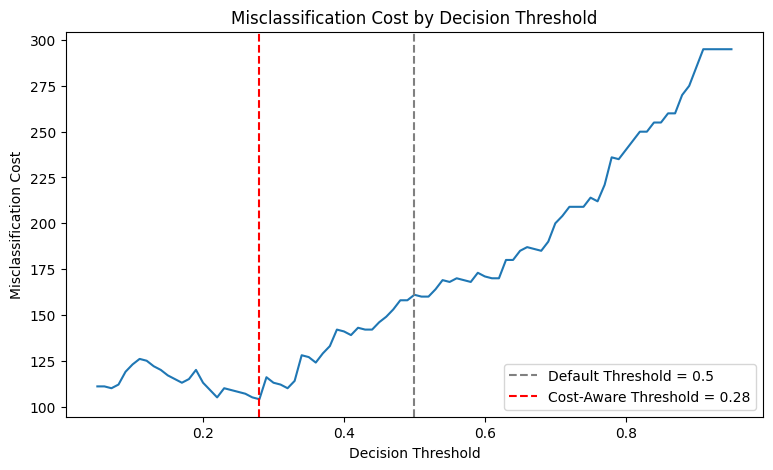

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["cost"]
)

plt.axvline(
    0.5,
    linestyle="--",
    color = 'grey',
    label="Default Threshold = 0.5"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    color = 'red',
    label=f"Cost-Aware Threshold = {best_threshold:.2f}"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Misclassification Cost")
plt.title("Misclassification Cost by Decision Threshold")
plt.legend()

plt.show()

### 임계값 변화에 따른 성능 확인

---

### Performance Changes Across Thresholds

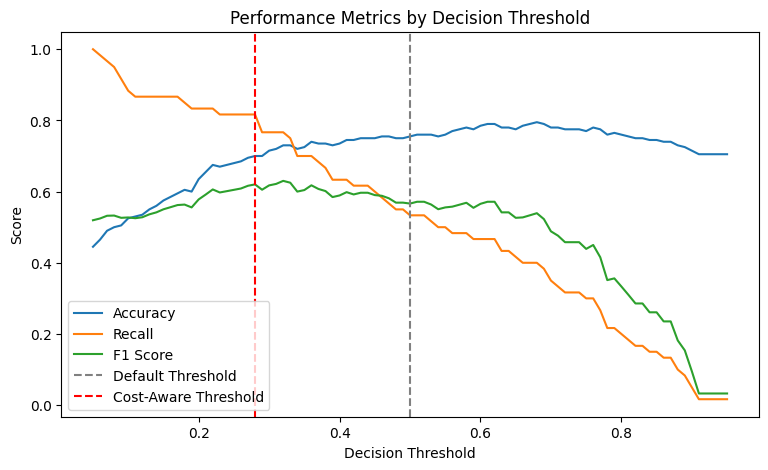

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["accuracy"],
    label="Accuracy"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    label="Recall"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    label="F1 Score"
)

plt.axvline(
    0.5,
    linestyle="--",
    color = 'grey',
    label="Default Threshold"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    color = 'red',
    label="Cost-Aware Threshold"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Performance Metrics by Decision Threshold")
plt.legend()

plt.show()

# 6. 최종 비교 - 테스트 데이터셋 적용 (Final Comparison on the Test Dataset)

In [ ]:
# 확률 (Predicted Probabilities)

y_test_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
# 기본 방식 (Default Method)

y_test_pred_default = model.predict(X_test)

In [ ]:
# 베스트 임계값 지정 (Apply the Best Threshold)
y_test_pred_cost = (y_test_prob >= best_threshold).astype(int)

### 최종 평가 함수

---

### Final Evaluation Function

In [ ]:
def evaluate_model(y_true, y_pred, strategy):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return {
        "Strategy": strategy,
        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "Precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "FP": fp,
        "FN": fn,
        "Total Cost": fp + (5 * fn)
    }

In [ ]:
# 결과 확인 (Review Final Results)

comparison = pd.DataFrame([
    evaluate_model(
        y_test,
        y_test_pred_default,
        "Default Threshold (0.5)"
    ),
    evaluate_model(
        y_test,
        y_test_pred_cost,
        f"Cost-Aware Threshold ({best_threshold:.2f})"
    )
])

comparison

,Strategy,Accuracy,Precision,Recall,F1,FP,FN,Total Cost
0,Default Threshold (0.5),0.755,0.617021,0.483333,0.542056,18,31,173
1,Cost-Aware Threshold (0.28),0.660,0.454545,0.666667,0.540541,48,20,148


# 7. 실험의 의의 (Significance of the Experiment)

### 📋 **현실적 의사결정을 위한 비용 고려 임계값 활용**

이 실험은 신용 위험 예측과 같이 오분류 비용이 비대칭적인 문제에서 **비용 고려 임계값(Cost-Aware Threshold)** 설정의 중요성을 확인합니다.

일반적으로 사용되는 0.5의 기본 임계값은 단순한 분류 기준으로 사용할 수 있지만, `Bad Credit` 고객을 `Good Credit`으로 잘못 분류하는 경우(False Negative)에 훨씬 큰 손실이 발생하는 현실적인 비즈니스 시나리오에서는 비용 측면에서 최적의 의사결정 기준이 아닐 수 있습니다.

`predict_proba()`를 통해 모델이 예측한 확률 분포를 활용하고, **오분류 비용 매트릭스**를 기반으로 최적의 임계값(본 실험에서는 0.28)을 탐색했습니다. 그 결과 전체 오분류 비용을 **173에서 148로**(`Default Threshold` 대비 `Cost-Aware Threshold`) 줄일 수 있음을 확인했습니다.

이는 모델을 단순한 통계적 성능 지표만으로 평가하는 것을 넘어, **실제 의사결정 비용을 반영하여 모델의 사용 방식을 조정할 수 있음**을 보여줍니다.

---

### 📋 **Using a Cost-Aware Threshold for Practical Decision-Making**

This experiment demonstrates the importance of setting a **Cost-Aware Threshold** in problems such as credit-risk prediction, where different types of misclassification have asymmetric costs.

The commonly used default threshold of 0.5 provides a standard classification rule, but it may not be the most cost-effective decision criterion in a realistic business scenario where incorrectly classifying a `Bad Credit` customer as `Good Credit` (False Negative) results in a substantially larger loss.

Using the probability distribution generated by `predict_proba()`, the experiment searches for an optimal threshold based on the **misclassification cost matrix**. In this experiment, the selected threshold is 0.28, reducing the total misclassification cost from **173 to 148** compared with the `Default Threshold`.

This result illustrates that model usage can be adjusted based on **real decision costs rather than relying solely on conventional statistical performance metrics**.